## Difference-in-Differences Analysis of RIGI law and Argentine Energy Stock Returns

### Overview
This project in causal inference uses a Difference-in-Differences model to estimate the effect of Argentina's **RIGI policy announcement on July 8, 2024** on the stock returns of major Argentine energy firms.

### Research Question
Did the implementation of RIGI generate a significant positive effect on the daily returns of Argentine energy companies relative to similar energy firms in Latin America?

### Empirical Design for DiD regression
- **Treated group:** YPF, PAM, VIST  (3 major energy firms based in Argentina)
- **Control group:** PBR, EC, GPRK   (3 regional peers based in Brazil, Colombia, and other neighboring countries)
- **Outcome variable:** Daily stock return  
- **Event date:** July 8, 2024  


### Import Modules

We will use:
- `pandas` and `numpy` 
- `yfinance` to download stock market data
- `matplotlib` for visualization
- `statsmodels` for linear regression 

In [9]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## 1. Download and Clean up Stock Price Data

I collect adjusted closing prices for firms in the treated and control groups, over pre-RIGI and post-RIGI thresholds.

### Groups
- **Treated:** Argentine firms expected to benefit directly from RIGI
- **Control:** Comparable regional energy firms outside Argentina

The timeline I chose starts well before the event date so that we can observe pre-treatment trends and construct a strong DiD model. 

In [10]:
# Create list of tickers for both Treatment and Control groups
treated_tickers = ['YPF', 'PAM', 'VIST']
control_tickers = ['PBR', 'EC', 'GPRK']
all_tickers = treated_tickers + control_tickers

# Timeline: We need a good pre-period for Parallel Trends, and a post-period for the effect.
start_date = '2023-01-01'
event_date = '2024-07-08'
end_date = '2024-09-01'

# 1. Download the data
raw_data = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=True)

# 2. Grab 'Close' prices
data = raw_data['Close']

# 3. Convert prices to daily returns (% change) and drop the first empty row
returns = data.pct_change().dropna()

[*********************100%***********************]  6 of 6 completed


## 2. Convert to Panel Data format

DiD regression needs a panel format for the data. I re-organize the data so that each row corresponds to an observation with firm and date.

In [11]:
# Panel data format
panel_data = returns.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Daily_Return')
panel_data

,Date,Ticker,Daily_Return
0,2023-01-04,EC,-0.008081
1,2023-01-05,EC,0.039715
2,2023-01-06,EC,0.073457
3,2023-01-09,EC,0.014599
4,2023-01-10,EC,0.008993
...,...,...,...
2497,2024-08-26,YPF,0.011865
2498,2024-08-27,YPF,0.012664
2499,2024-08-28,YPF,0.006484
2500,2024-08-29,YPF,0.032674


## 3. Construct our DiD Variables

- `treated`: dummy variable that = 1 for firms in the treatment group, 0 otherwise
- `post`: dummy variable that = 1 for dates on or after July 8, 2024, 0 otherwise
- `treated_post` = interaction term (`treated × post`)

This interaction term is the DiD estimator.

In [12]:
# Define who is in the Treatment Group (receiving RIGI policy) 
treatment_group = (panel_data['Ticker'] == 'YPF') | \
             (panel_data['Ticker'] == 'PAM') | \
             (panel_data['Ticker'] == 'VIST')

# Create variables for DiD regression

# 1. Group Dummy (treated)
panel_data['treated'] = 0
panel_data.loc[treatment_group, 'treated'] = 1

# 2. Time dummy (post) 
# 3. Interaction term (treated_post) 
panel_data = panel_data.assign(
    post = (panel_data.get('Date') >= '2024-07-08').astype(int)
).assign(
    treated_post = lambda df: df.get('treated') * df.get('post')
)
panel_data.head()


,Date,Ticker,Daily_Return,treated,post,treated_post
0,2023-01-04,EC,-0.008081,0,0,0
1,2023-01-05,EC,0.039715,0,0,0
2,2023-01-06,EC,0.073457,0,0,0
3,2023-01-09,EC,0.014599,0,0,0
4,2023-01-10,EC,0.008993,0,0,0


## 4. Estimate the Difference-in-Differences Model using OLS

Model: $$
Daily\_Return_{it} = \beta_0 + \beta_1 \, treated_i + \beta_2 \, post_t + \beta_3 \, (treated_i \times post_t) + \epsilon_{it}
$$

In [13]:
# Define the regression formula
formula = 'Daily_Return ~ treated + post + treated_post'

# Run OLS 
model = smf.ols(formula=formula, data=panel_data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Daily_Return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.639
Date:                Sun, 29 Mar 2026   Prob (F-statistic):              0.178
Time:                        16:30:35   Log-Likelihood:                 5507.7
No. Observations:                2502   AIC:                        -1.101e+04
Df Residuals:                    2498   BIC:                        -1.098e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0011      0.001      1.414   

### Interpretation

The coefficient on the interaction term is the DiD estimator. It reflects the additional change in returns for firms in the treatment group after the policy, relative to firms in the control group.

Our estimated coefficient is positive, which means that treated firms experienced higher returns following RIGI. However, statistical significance depends on our choice of standard error specification.

This indicates that inference is not fully robust. Given the panel structure of the data, clustered standard errors are more appropriate, but the small number of firms suggest that we should interpret with caution. 

## 5. Run OLS again using Clustered Standard Errors

This time we use standard errors clustered by ticker, since stock returns for the same firm may be correlated over time.

This yields a more conservative but honest result. Once we account for autocorrelation, our estimated effect becomes statistically significant.

In [14]:
# Re-run OLS with Clustered Standard Errors by ticker
model = smf.ols(formula=formula, data=panel_data).fit(
    cov_type='cluster', 
    cov_kwds={'groups': panel_data['Ticker']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Daily_Return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     6.098
Date:                Sun, 29 Mar 2026   Prob (F-statistic):             0.0400
Time:                        16:30:36   Log-Likelihood:                 5507.7
No. Observations:                2502   AIC:                        -1.101e+04
Df Residuals:                    2498   BIC:                        -1.098e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0011      0.001      1.658   

# Test Validation Assumptions

## 6. Parallel Trends Assumption

In the absence of treatment, the treatment and control groups would have followed similar trends over time.

I plot the average daily returns of the treatment and control groups over time.

Note: the noticeable spike in Argentine returns occurs briefly during Javier Milei's election. Aside from this short spike, pre-treatment trends move very similarly for both the treatment and control groups.

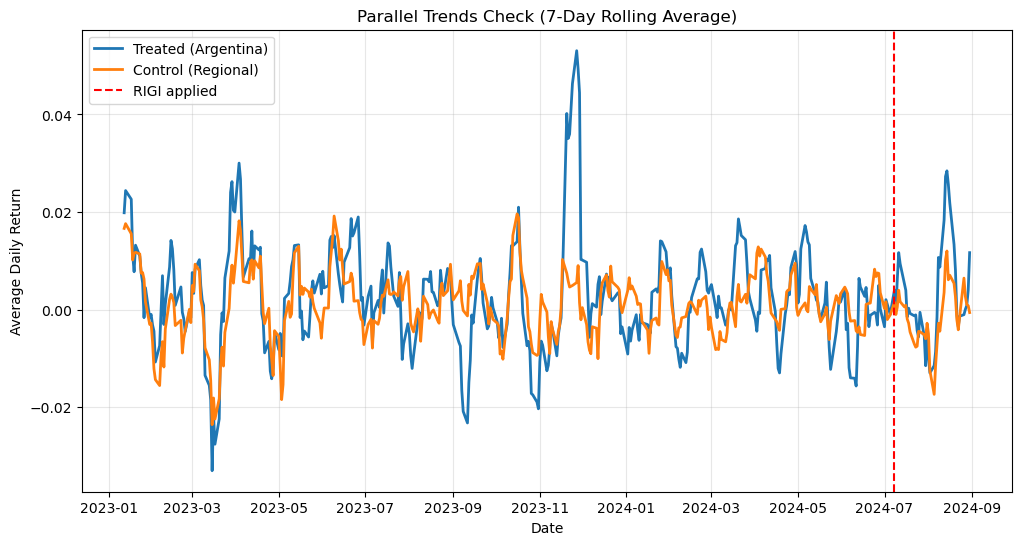

In [15]:
treated = panel_data[panel_data['treated'] == 1]
control = panel_data[panel_data['treated'] == 0]

# Average daily return by date for treatment and control groups
treated_avg = treated.groupby('Date', as_index=False)['Daily_Return'].mean()
control_avg = control.groupby('Date', as_index=False)['Daily_Return'].mean()

# 7-day rolling average
treated_avg['smoothed'] = treated_avg['Daily_Return'].rolling(7).mean()
control_avg['smoothed'] = control_avg['Daily_Return'].rolling(7).mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(treated_avg['Date'], treated_avg['smoothed'], label='Treated (Argentina)', linewidth=2)
plt.plot(control_avg['Date'], control_avg['smoothed'], label='Control (Regional)', linewidth=2)

plt.axvline(pd.to_datetime('2024-07-08'), linestyle='--', color='red', label='RIGI applied')

plt.title('Parallel Trends Check (7-Day Rolling Average)', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Average Daily Return')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7. Placebo Test

To strengthen the design, I run a placebo DiD test using only pre-RIGI data and assigning a fake treatment date.

If the placebo model's coefficient is statistically insignificant, it backs the idea that our main result is tied to the true policy timing rather than random chance.

In [16]:
# 1. Filter for data ONLY before RIGI was passed
placebo_df = panel_data[panel_data.get('Date') < '2024-07-08']

# 2. Assign placebo post-period (01/01/2024) and new interaction term
placebo_df = placebo_df.assign(
    post_placebo = (placebo_df.get('Date') >= '2024-01-01').astype(int)
).assign(
    interaction_placebo = lambda df: df.get('treated') * df.get('post_placebo')
)

# 3. Run placebo OLS (using clustered SEs)
placebo_formula = 'Daily_Return ~ treated + post_placebo + interaction_placebo'
placebo_model = smf.ols(formula=placebo_formula, data=placebo_df).fit(
    cov_type='cluster', 
    cov_kwds={'groups': placebo_df['Ticker']}
)

print(placebo_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Daily_Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     24.27
Date:                Sun, 29 Mar 2026   Prob (F-statistic):            0.00208
Time:                        16:30:37   Log-Likelihood:                 4956.3
No. Observations:                2262   AIC:                            -9905.
Df Residuals:                    2258   BIC:                            -9882.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0012    

### Interpretation

The placebo regression produces a small and statistically insignificant coefficient on the interaction term.

Thus, when we assign the policy to a random (and false) time period, we do not find any effect. We can use this to strengthen our claim that the treatment effect we initially found was linked to RIGI and not random chance. 

## 9. Cumulative Estimated Treatment Effect

Finally, I visualize how the estimated DiD treatment effect accumulates over the post-RIGI period. 

In [17]:
# Estimated treatment effect from the DiD model
rigi_effect = model.params['treated_post']

# Create one row for each post-RIGI date
cra_data = (
    panel_data[panel_data['Date'] >= '2024-07-08']
    [['Date']]
    .drop_duplicates()
    .sort_values('Date')
    .reset_index(drop=True)
)

# Accumulate the estimated daily effect over the post period
cra_data['cumulative_effect'] = (rigi_effect * np.arange(1, len(cra_data) + 1)) * 100

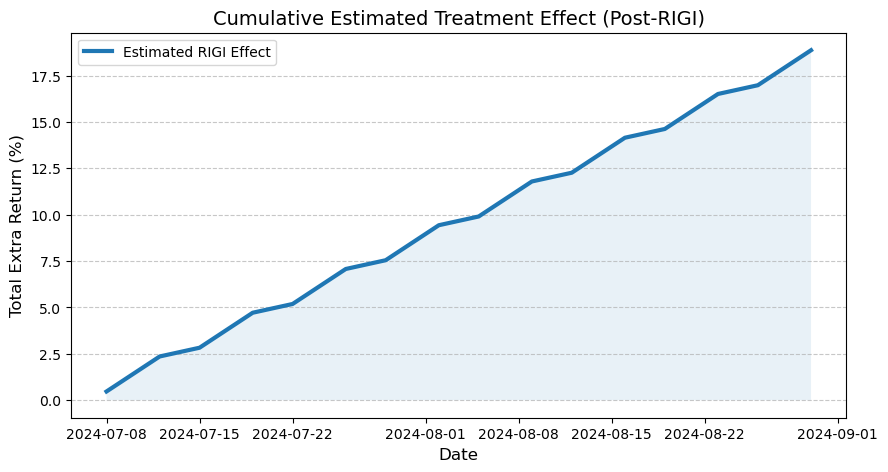

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    cra_data['Date'],
    cra_data['cumulative_effect'],
    linewidth=3,
    label='Estimated RIGI Effect'
)

plt.fill_between(
    cra_data['Date'],
    0,
    cra_data['cumulative_effect'],
    alpha=0.1
)

plt.title('Cumulative Estimated Treatment Effect (Post-RIGI)', fontsize=14)
plt.ylabel('Total Extra Return (%)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 10. Conclusion

This project applies a (simplified) Difference-in-Differences framework to study the stock market response to Argentina's RIGI policy.

### Interpretation
- The `treated_post` coefficient captures whether treated Argentine firms outperformed their regional peers after the date RIGI was applied.

### I demonstrate how to...
- Clean stock data to retrieve a panel dataset in Python
- Construct and interpret a DiD model
- Use clustered standard errors
- Check for parallel trends
- Construct and interpret placebo test model 
- Visualize the cumulative treatment effect 

### Limitations
- The number of firms is small, so results found after implementing clustered SEs should be interpreted with caution.
- The statistical significance of our DiD estimator changes when we change our SE specification,
  which implies that our inference is not fully robust.
- This DiD analysis is simplified; it relies on a small time period and sample of firms, which could limit external validity. 